In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

In [4]:
pi   = math.pi
hx_boltz   = 1.38065e-16  ## J/K
hx_mele   = 9.10938e-28 ## kg
h    = 6.62607e-27   ## Js
hx_hbar = h/(2*pi)   ## Js
mu0  = 1.25664e-6  ## H/m
hx_qele   = 4.80320e-10  ## C

In [5]:
# Conductivity --------------------------
def SpizterConductivity(T, nele, z):
    ll = loglambdaSpitzer(T, nele, z)
    const = (8/pi) ** (3/2) * (hx_boltz**(7/2) / (hx_qele**4 * (hx_mele) ** (1/2)))
    sigma = (1/(1+3.3/z)) * (T**(5/2)/(z*ll))
    return const * sigma

def loglambdaSpitzer(T,n,Z):
    bmax = np.sqrt((hx_boltz * T) / (4*pi*hx_qele**2*n))
    bmin = [(Z*hx_qele**2)/(3*hx_boltz*T), (hx_hbar)/np.sqrt(12*hx_boltz*T*hx_mele)]
    ll = np.log(1+bmax/max(bmin))
    return ll

def loglambdaLeeMore(tele, nele, tion, zbar):
    ll_floor = 1.0
    nion = nele/zbar
    R0 = (4*math.pi*nion/3)**(-1./3)
    Tf = hx_hbar**2 / (2*hx_mele) * (3 * math.pi **2 * nele)**(2./3) / hx_boltz; 
    debye_len = 1/math.sqrt((4* math.pi * hx_qele**2 * nele)/(hx_boltz*math.sqrt(tele**2 + Tf**2)) + 4*math.pi*nion *zbar**2 *hx_qele**2 /(hx_boltz*tion) )
    bmax = max(debye_len,R0)
    bmin_classic = zbar * hx_qele**2 / (3*hx_boltz*tele)
    bmin_quantum = hx_hbar / (2*math.sqrt(3*hx_boltz*tele*hx_mele))
    bmin = max(bmin_classic, bmin_quantum)
    ll = max(0.5*math.log((1+(bmax/bmin)**2), math.e), ll_floor)
    return ll

def eq_time(nele, zbar, tele, logLambda):
    A = (4/3) * (2 * math.pi / hx_mele) ** (1/2)
    num = nele * zbar * hx_qele ** 4 * logLambda
    denom = (hx_boltz * tele) ** (3/2)
    return A * (num / denom)


def calc_fermi_energy(nion):
    fermi_energy = hx_hbar ** 2.0 * (3.0 * math.pi ** 2.0 * nion) ** (2./3.) / 2.0 / hx_mele
    return fermi_energy
  

def calc_theta(tele, nion):
    fermi_energy = calc_fermi_energy(nion)
    theta = (tele * hx_boltz) / fermi_energy
    return theta
    
def calc_mu(tele, nion):
    theta = calc_theta(tele, nion)    
    A = -3./2. * math.log((theta), math.e)
    B = math.log((4./3./math.sqrt(math.pi)), math.e)
    C = 0.25054 * theta ** (-1.858) + 0.072 * theta ** (-1.858/2.0)
    D = 1 + 0.25054 * theta ** (-0.858)
    mu_ichimaru = (A + B + C/D)
    return -mu_ichimaru

def LeeMoreConductivity(z, nele, T, Tion):
    nion = nele/z
    mu_div_kT = calc_mu(Tion, nion)
    tau = eq_time(nele, z, T, loglambdaLeeMore(T, nele, Tion, z))
    a1 = 13.5
    a2 = 0.976
    a3 = 0.437
    b2 = 0.51
    b3 = 0.126
    if mu_div_kT > 20:
        y = mu_div_kT
    elif mu_div_kT < -15:
        y = np.exp(mu_div_kT)
    else:
        y = np.log(1 + np.exp(mu_div_kT))
    
    A_beta = (a1 + a2*y + a3*y**2 ) / (1 + b2*y + b3*y**2)  
    K = (nele*hx_boltz*(hx_boltz * T) * tau) / hx_mele * A_beta
    return K


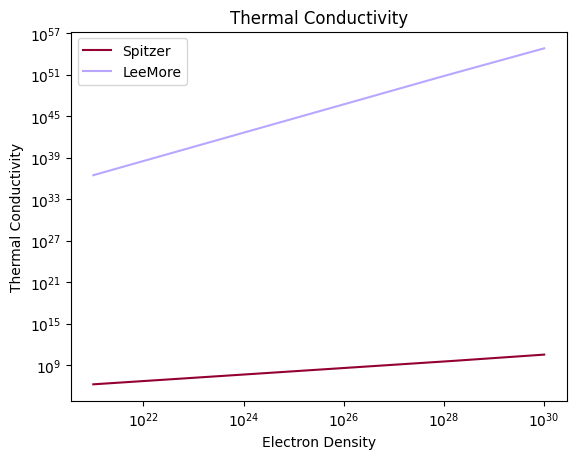

In [8]:
## Data -----------------------------------
nele = np.linspace(1e21,1e30,200)
Z = 1
T = 23209 
Tion = 20000
LS = []
LM = []
for i in range(len(nele)):
    LS.append(SpizterConductivity(T, nele[i], Z))
    LM.append(LeeMoreConductivity(Z, nele[i], T, Tion))
    
    
plt.plot(nele, LS, c = "#940034", label = "Spitzer")
plt.plot(nele, LM, c = "#B9A6FF", label="LeeMore")
plt.title("Thermal Conductivity")
plt.xlabel("Electron Density")
plt.legend()
plt.ylabel("Thermal Conductivity")
plt.yscale("log")
plt.xscale("log")
plt.savefig("/Users/admin/Desktop/Plasma/nolog.png", dpi = 800)

    